# Single trial analysis

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pyaldata as pyal
import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.dataTools as dt
from tools.params import colors
import tools.kinematics as kin
import scipy

from tqdm import tqdm
import tools.viz.utilityTools as vizutils
import tools.decoding as decode

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB



In [25]:
SESSIONS = [
    "M061_2025_03_06_14_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_27_16_00",
    # 'M086_2025_12_11_15_00',
    # 'M086_2025_12_10_15_00'
]
session = SESSIONS[0]
td_ = dsp.load_and_preprocess_trials_from_sess(SESSIONS[0], std=0.03, run_pca=False)



##### Loading and preprocessing ######


/root/repos/pyaldata/pyaldata/data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)

##### Dropping unsteady running trials ######
bhv column not found, adding it
otsu immobility threshold: 2.9536
drop_unsteady_running_trials: dropping 78 of 333 trials (23.4%)

##### Calculating perturbation metric ######
compute_power_in_bhv_concat_td: dropping 11 trial(s) with peak_mean_freq < 2 Hz


In [26]:
# td = dt.add_bhv(td_, bhv_fields=["pos_keypoints"])
td = pyal.restrict_to_interval(
    td_, start_point_name="idx_sol_on", rel_start=-200, rel_end=200,
)
# td, _, _ = kin.rotate_bhv_td(td, validate=False, verbose=False)

In [27]:
td.phases.values[0].shape

(401, 12)

np.float64(13.278214290698276)

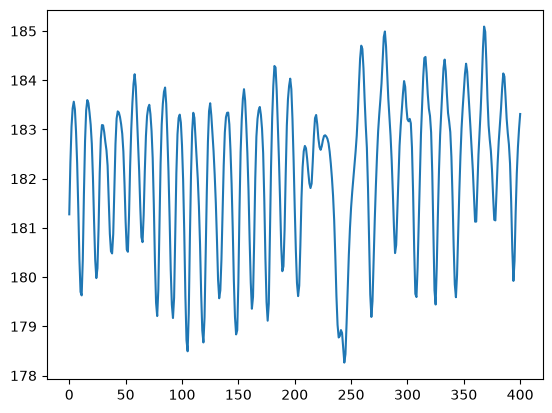

In [5]:
plt.plot(td.bhv.values[0][:, 5])
np.var(td.bhv.values[0][200:350, 0])

In [14]:
np.var(td.bhv.values[0][0:150, 0])

np.float64(1.3469224449168924)

## Choosing the best keypoint for phase estimation

Baseline window only (samples 0:200, i.e. before `idx_sol_on`), third axis of each keypoint's rotated body frame (index 2 -> ml). We rank keypoints by how concentrated their power is at the stride frequency (spectral SNR), not by raw amplitude, since a large but non-rhythmic signal (postural drift, tracking jitter) is useless for phase.

In [19]:
import scipy.signal as sgnl

kps = Params.pos_keypoints
n_kp = len(kps)
T0 = 200  # baseline window: samples 0:200, i.e. before idx_sol_on
AXIS = 2  # third axis of each rotated keypoint block -> ml

fs = 1 / td.bin_size.values[0]
n_trials = len(td)

# X[trial, time, keypoint] = ml trace of that keypoint, baseline window only
X = np.full((n_trials, T0, n_kp), np.nan)
for i in range(n_trials):
    mat = td.bhv_rot.values[i]
    for k in range(n_kp):
        col = 3 * k + AXIS
        seg = mat[:T0, col]
        X[i, : len(seg), k] = seg

print(f"fs = {fs:.2f} Hz, X shape = {X.shape}, nan frac = {np.isnan(X).mean():.3f}")

fs = 100.00 Hz, X shape = (244, 200, 19), nan frac = 0.000


stride-frequency peak (grand average, 1.0-15.0 Hz): 6.25 Hz


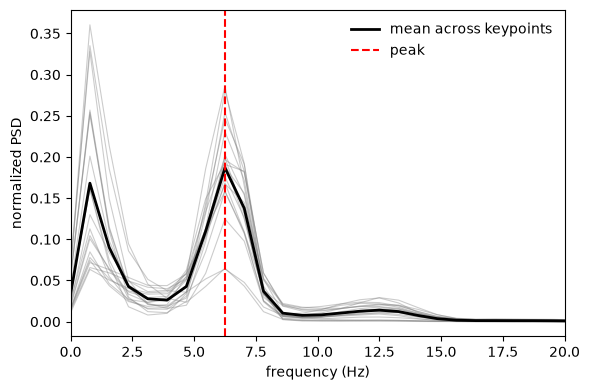

In [26]:
# Welch PSD per keypoint, averaged over trials (drop trials with any NaN for that keypoint)
psd_list, freqs = [], None
for k in range(n_kp):
    ok = ~np.isnan(X[:, :, k]).any(axis=1)
    xk = X[ok, :, k]
    xk = xk - xk.mean(axis=1, keepdims=True)
    f, pxx = sgnl.welch(xk, fs=fs, nperseg=min(128, T0), axis=1)
    psd_list.append(pxx.mean(axis=0))
    freqs = f
psd = np.array(psd_list)  # (n_kp, n_freqs)

# find the stride-frequency peak from the grand-average normalized spectrum,
# restricted to a plausible mouse-locomotion band, instead of hardcoding a frequency
norm_psd = psd / psd.sum(axis=1, keepdims=True)
band_lo, band_hi = 1.0, 15.0
band_mask = (freqs >= band_lo) & (freqs <= band_hi)
grand = norm_psd.mean(axis=0)
peak_f = freqs[band_mask][np.argmax(grand[band_mask])]
print(f"stride-frequency peak (grand average, {band_lo}-{band_hi} Hz): {peak_f:.2f} Hz")

fig, ax = plt.subplots(figsize=(6, 4))
for k in range(n_kp):
    ax.plot(freqs, norm_psd[k], color="grey", alpha=0.4, lw=0.8)
ax.plot(freqs, grand, color="k", lw=2, label="mean across keypoints")
ax.axvline(peak_f, color="red", ls="dashed", label=f"peak")
ax.set_xlim(0, 20)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("normalized PSD")
ax.legend(frameon=False)
fig.tight_layout()

top 5: ['shoulder_center', 'hip_center', 'right_elbow', 'right_foot', 'right_ankle']


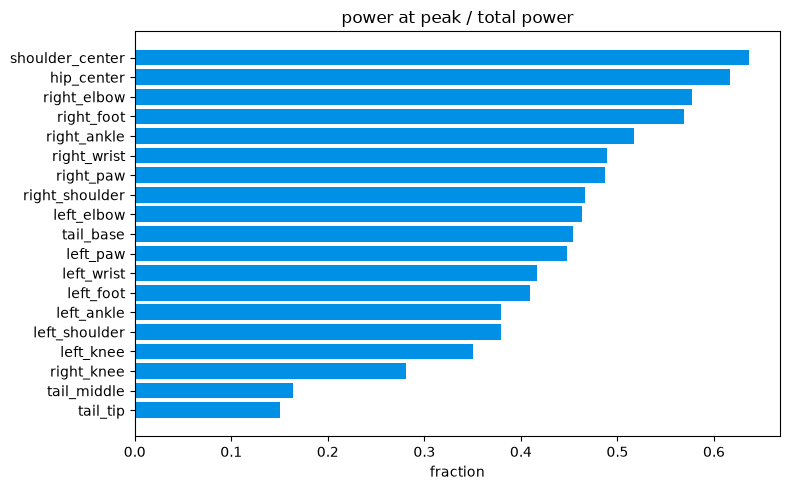

In [28]:
# spectral concentration ratio: fraction of each keypoint's power sitting in a narrow
# band around the shared stride-frequency peak -- this is the SNR-like criterion,
# not raw amplitude, for picking a phase-estimation keypoint
band = (freqs >= peak_f - 1.5) & (freqs <= peak_f + 1.5)
conc = psd[:, band].sum(axis=1) / psd.sum(axis=1)

order = np.argsort(conc)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([kps[i] for i in order][::-1], conc[order][::-1], color="#0091E6")
ax.set_xlabel("fraction")
ax.set_title(f"power at peak / total power")
fig.tight_layout()

print("top 5:", [kps[i] for i in order[:5]])

corr(spectral concentration, autocorr peak) = 0.41
top 5 by autocorrelation: ['hip_center', 'tail_base', 'right_ankle', 'shoulder_center', 'right_foot']


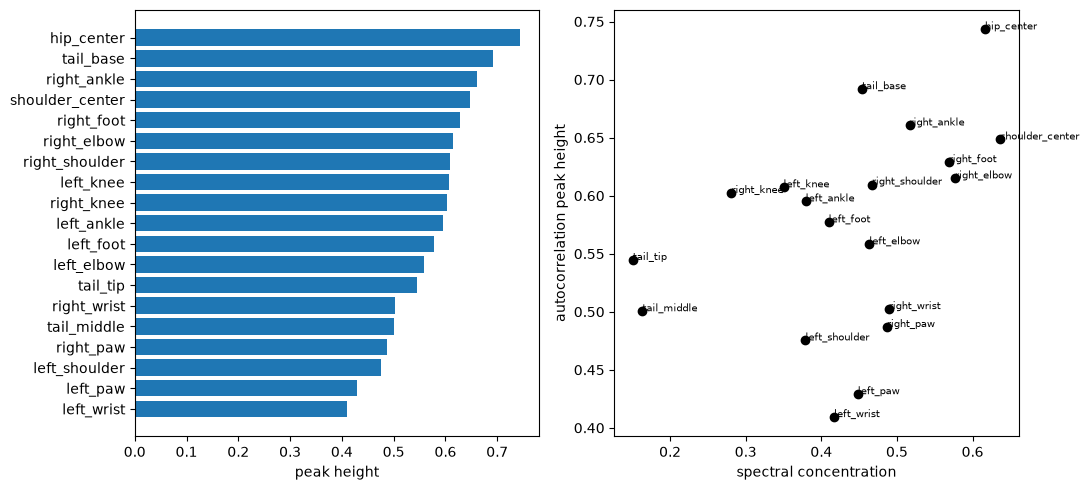

In [33]:
# cross-check with a time-domain periodicity metric (autocorrelation peak height at the
# stride period), independent of the Welch/FFT-based concentration ratio above -- if the
# two rankings agree, that's good evidence the choice isn't an artifact of one method
def autocorr_peak(x, fs, f_lo=1, f_hi=15):
    x = x - x.mean()
    ac = np.correlate(x, x, mode="full")
    ac = ac[ac.size // 2 :]
    ac = ac / ac[0]
    lags = np.arange(ac.size) / fs
    mask = (lags >= 1 / f_hi) & (lags <= 1 / f_lo)
    return ac[mask].max() if mask.any() else np.nan

acpeak = np.full(n_kp, np.nan)
for k in range(n_kp):
    ok = ~np.isnan(X[:, :, k]).any(axis=1)
    xk = X[ok, :, k]
    acpeak[k] = np.nanmean([autocorr_peak(xk[i], fs) for i in range(xk.shape[0])])

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
order2 = np.argsort(acpeak)[::-1]
axs[0].barh([kps[i] for i in order2][::-1], acpeak[order2][::-1])
axs[0].set_xlabel("peak height")

axs[1].scatter(conc, acpeak, color="k")
for k in range(n_kp):
    axs[1].annotate(kps[k], (conc[k], acpeak[k]), fontsize=7)
axs[1].set_xlabel("spectral concentration")
axs[1].set_ylabel("autocorrelation peak height")
fig.tight_layout()

print(f"corr(spectral concentration, autocorr peak) = {np.corrcoef(conc, acpeak)[0, 1]:.2f}")
print("top 5 by autocorrelation:", [kps[i] for i in order2[:5]])

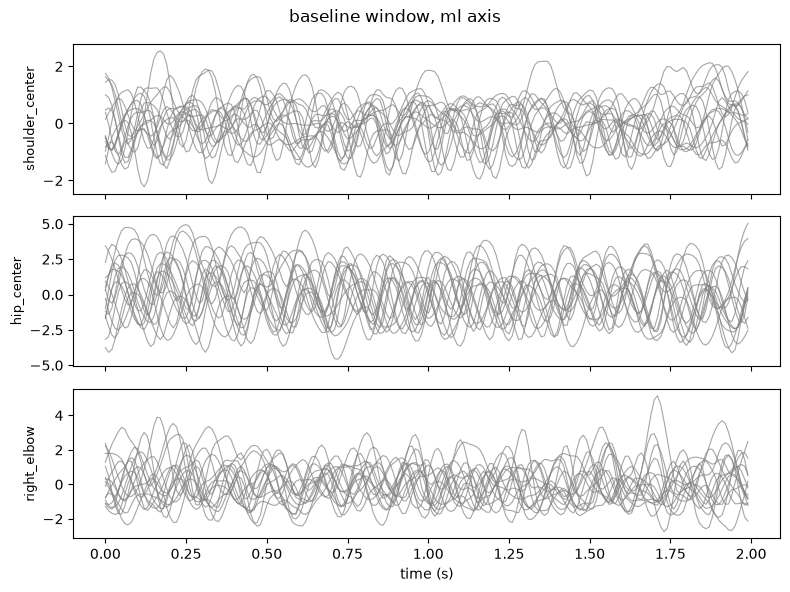

In [36]:
# sanity check: eyeball a few baseline-window traces (ml axis) for the top-3 keypoints
top3 = [kps[i] for i in order[:3]]
fig, axs = plt.subplots(len(top3), 1, figsize=(8, 6), sharex=True)
t = np.arange(T0) / fs
for ax, kp in zip(axs, top3):
    k = kps.index(kp)
    for i in range(min(15, n_trials)):
        ax.plot(t, X[i, :, k], color="grey", alpha=0.7, lw=0.8)
    ax.set_ylabel(kp, fontsize=9)
axs[-1].set_xlabel("time (s)")
fig.suptitle("baseline window, ml axis")
fig.tight_layout()

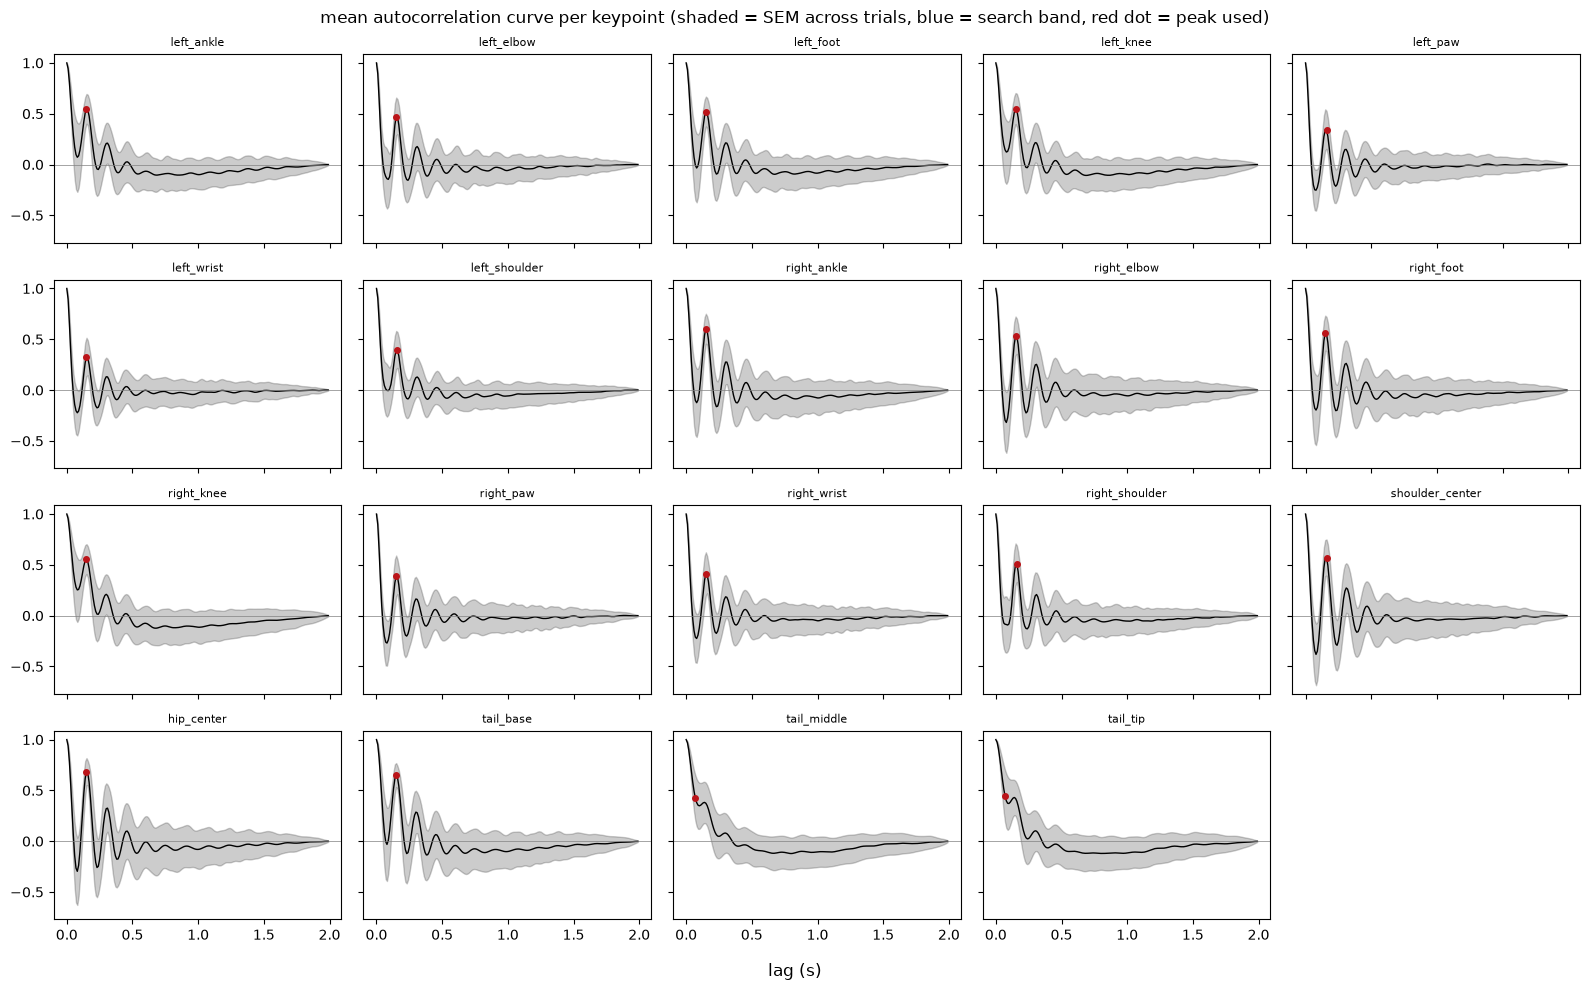

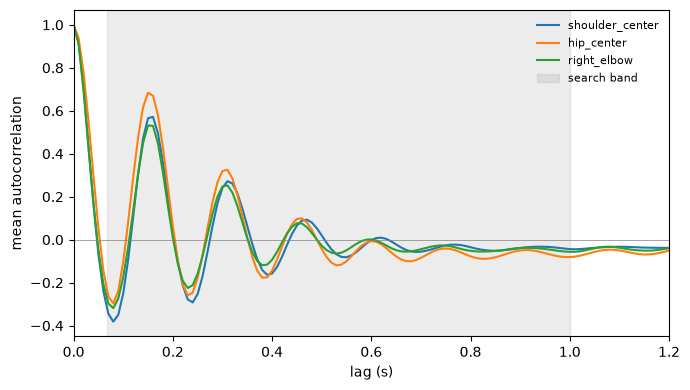

In [31]:
# --- double-check: plot the actual autocorrelation curves, not just the peak scalar ---
def autocorr_curve(x, fs):
    x = x - x.mean()
    ac = np.correlate(x, x, mode="full")
    ac = ac[ac.size // 2 :]
    ac = ac / ac[0]
    lags = np.arange(ac.size) / fs
    return lags, ac

f_lo, f_hi = 1, 15  # same locomotion band used in autocorr_peak
lag_lo, lag_hi = 1 / f_hi, 1 / f_lo

curves = {}  # keypoint -> (n_trials, n_lags) array of per-trial autocorrelation curves
for k in range(n_kp):
    ok = ~np.isnan(X[:, :, k]).any(axis=1)
    xk = X[ok, :, k]
    lags_full, _ = autocorr_curve(xk[0], fs)
    curves[kps[k]] = np.array([autocorr_curve(xk[i], fs)[1] for i in range(xk.shape[0])])

band = (lags_full >= lag_lo) & (lags_full <= lag_hi)

# grid of all keypoints: mean curve +/- SEM across trials, shaded search band,
# dot at the lag that wins (i.e. exactly what autocorr_peak reports as the height)
fig, axs = plt.subplots(4, 5, figsize=(16, 10), sharex=True, sharey=True)
for ax, kp in zip(axs.flat, kps):
    cs = curves[kp]
    m, se = cs.mean(0), cs.std(0, ddof=1) #/ np.sqrt(cs.shape[0])
    ax.plot(lags_full, m, color="k", lw=1)
    ax.fill_between(lags_full, m - se, m + se, color="k", alpha=0.2)
    # ax.axvspan(lag_lo, lag_hi, color="#0091E6", alpha=0.12)
    peak_lag = lags_full[band][np.argmax(m[band])]
    ax.plot(peak_lag, m[band].max(), "o", color="#BB1419", ms=4)
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_title(kp, fontsize=8)
for ax in axs.flat[n_kp:]:
    ax.axis("off")
fig.suptitle("mean autocorrelation curve per keypoint (shaded = SEM across trials, blue = search band, red dot = peak used)")
fig.supxlabel("lag (s)")
fig.tight_layout()

# zoomed overlay of the top-3 keypoints from the spectral-concentration ranking
fig, ax = plt.subplots(figsize=(7, 4))
for kp in top3:
    m = curves[kp].mean(0)
    ax.plot(lags_full, m, label=kp)
ax.axvspan(lag_lo, lag_hi, color="grey", alpha=0.15, label="search band")
ax.set_xlim(0, 1.2)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("lag (s)")
ax.set_ylabel("mean autocorrelation")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## Implement FIR filter and causal Hilbert

In [6]:
def kp_dim_to_idx(kp, dim=None, feat_list=Params.pos_keypoints):
    idx = np.argwhere(np.array(feat_list) == kp).item()
    if dim is not None:
        idx = idx * 3 + dim
    else:
        idx = [idx * 3 + d for d in range(3)]
    return idx

In [9]:
# X = np.stack(td.bhv_rot.values)
phases = np.stack(td.phases.values)
# hip_center_ml = X[:, :, kp_dim_to_idx('hip_center', dim=2)]

In [27]:
td.bhv_concat.values[0].shape

(1100, 12)

In [30]:
td.phases.values[tr].shape

(401, 12)

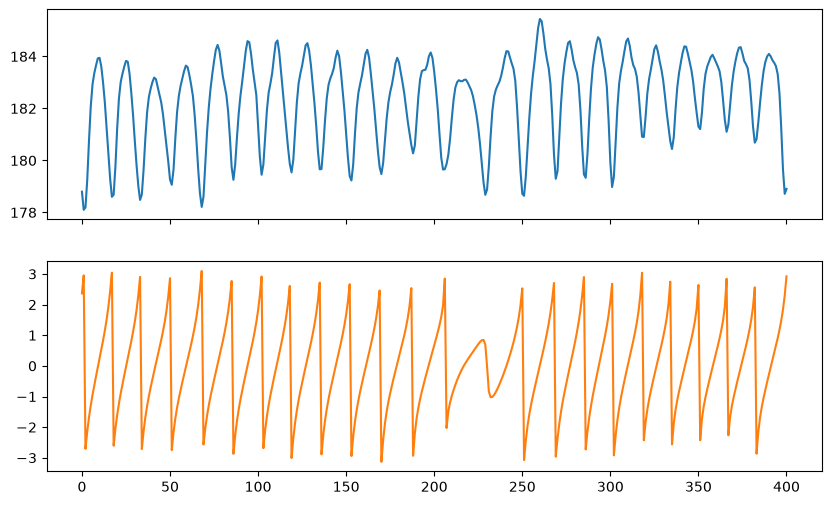

In [33]:
tr = 10
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex='all')
ax[0].plot(td.bhv.values[tr][:, 5])
ax[1].plot(td.phases.values[tr][:, 1], color='C1')

In [101]:
hip_center_ml.shape

(244, 401)

In [79]:
analytic_signal[0]

np.complex128(1.0000000000000004-0.29786270895488004j)

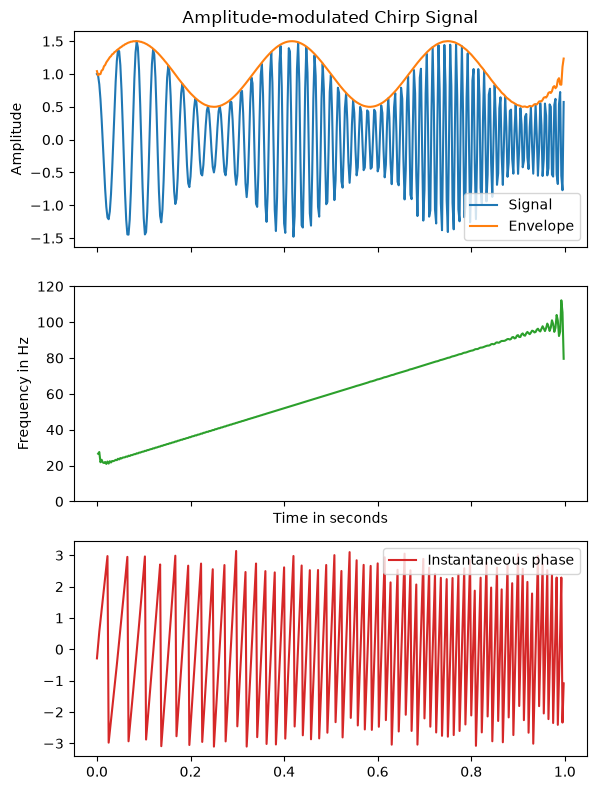

In [93]:
from scipy.signal import hilbert, chirp

duration, fs = 1, 400
t = np.arange(int(fs*duration)) / fs
signal = chirp(t, 20.0, t[-1], 100.0)
signal *= (1.0 + 0.5 * np.sin(2.0*np.pi*3.0*t) )


analytic_signal = hilbert(signal)
amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
instantaneous_frequency = np.diff(instantaneous_phase) / (2.0*np.pi) * fs
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharex='all', tight_layout=True, figsize=(6, 8))
ax0.set_title("Amplitude-modulated Chirp Signal")
ax0.set_ylabel("Amplitude")
ax0.plot(t, signal, label='Signal')
ax0.plot(t, amplitude_envelope, label='Envelope')
ax0.legend()
ax1.set(xlabel="Time in seconds", ylabel="Frequency in Hz", ylim=(0, 120))
ax1.plot(t[1:], instantaneous_frequency, 'C2-',
         label='Instantaneous Frequency')

# ax1.set(xlabel="Time in seconds", ylabel="Frequency in Hz", ylim=(0, 120))
ax2.plot(t, np.angle(analytic_signal), 'C3-',
         label='Instantaneous phase')
ax2.legend()
plt.show()

## Causal phase estimation

Two simple, self-contained functions:
1. `causal_phase_estimator` -- causal band-pass filter + causal (FIR) Hilbert transform, giving instantaneous phase/amplitude using only past+current samples (no `filtfilt`, no FFT-based `scipy.signal.hilbert`). Includes a `warmup` sample count: filter output before that index is transient, not a valid phase.
2. `trial_peak_frequency` -- estimate the stride frequency from a single trial's own pre-onset window (still causal: only uses that trial's own past samples), so you can check whether per-trial re-centering of the filter is worth it (see spread check below).

In [155]:
def causal_hilbert_fir(numtaps, window="hamming"):
    """Causal FIR approximation of the Hilbert transform (windowed ideal quadrature filter).

    scipy.signal.remez(..., type="hilbert") is numerically unstable for a band this narrow
    and far from DC/Nyquist (returns NaNs) -- the classic windowed-sinc design is stable and
    is what this uses instead. Only odd taps get a nonzero coefficient (2 / (pi * n)); this
    is a Type III linear-phase filter, so its group delay is a single constant,
    (numtaps - 1) // 2 samples, matching the band-pass filter's own delay below.
    """
    if numtaps % 2 == 0:
        numtaps += 1
    M = (numtaps - 1) // 2
    n = np.arange(-M, M + 1)
    h = np.zeros_like(n, dtype=float)
    odd = n % 2 != 0
    h[odd] = 2.0 / (np.pi * n[odd])
    return h * sgnl.get_window(window, numtaps)


def causal_phase_estimator(x, fs, center_freq, bandwidth=2.0, numtaps=71):
    """Causal band-pass + causal Hilbert -> instantaneous phase and amplitude.

    Both filters are linear-phase FIR (constant group delay), so the combined delay is
    known exactly: 2 * (numtaps - 1) // 2 samples. Output before that many samples have
    elapsed is filter transient, not a valid estimate -- see the returned `warmup`.
    """
    lo, hi = center_freq - bandwidth / 2, center_freq + bandwidth / 2
    bp_taps = sgnl.firwin(numtaps, [lo, hi], pass_zero=False, fs=fs)
    hilb_taps = causal_hilbert_fir(numtaps)

    xf = sgnl.lfilter(bp_taps, 1.0, x)     # causal band-pass, delay d
    xq = sgnl.lfilter(hilb_taps, 1.0, xf)  # causal quadrature branch, +d more delay

    d = (numtaps - 1) // 2
    xr = np.full_like(xf, np.nan)
    xr[d:] = xf[:-d]  # delay the real branch by d to align it with xq's extra delay
    phase = np.arctan2(xq, xr)
    amp = np.hypot(xq, xr)
    warmup = 2 * d
    return phase, amp, warmup

In [156]:
hip_center_ml[0]
phase, amp, warmup = causal_phase_estimator(hip_center_ml[0], fs=100, center_freq=6.25, bandwidth=2)

In [159]:
phase[:100]

array([        nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
        1.78480549,  2.05440635,  2.35162921,  2.68111976,  3.03410486,
       -2.87626979, -2.49651739, -2.1161547 , -1.73835623, -1.36004453,
       -0.977439  , -0.58845222, -0.19337143,  0.20491685,  0.60356571,
        1.0005606 ,  1.39588596,  1.79067058,  2.18639957,  2.5839773 ,
        2.98327171, -2.89956137, -2.49877448, -2.09764403, -1.69570301,
       -1.29216112, -0.88642275, -0.47837981, -0.06837252,  0.34311168,
        0.755833  ,  1.16995429,  1.58594599,  2.00425781,  2.42

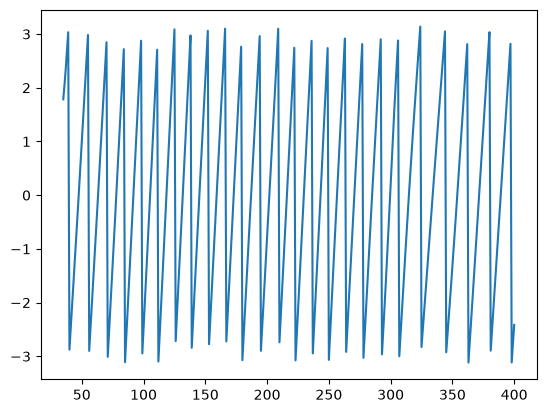

In [160]:
plt.plot(phase)

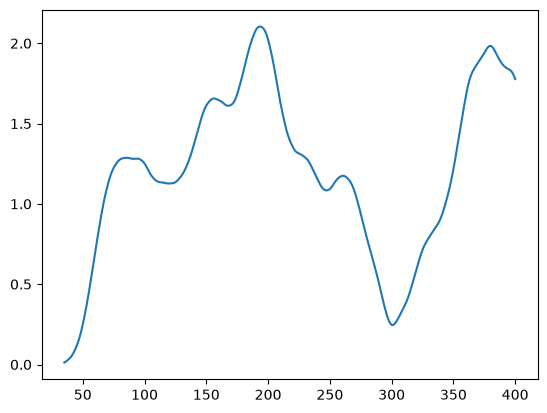

In [161]:
plt.plot(amp)

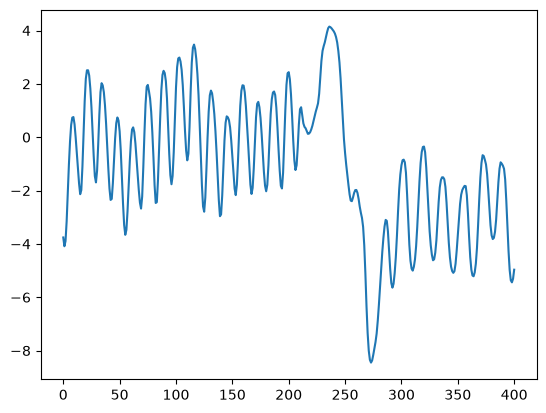

In [ ]:
plt.plot(hip_center_ml[0, :])

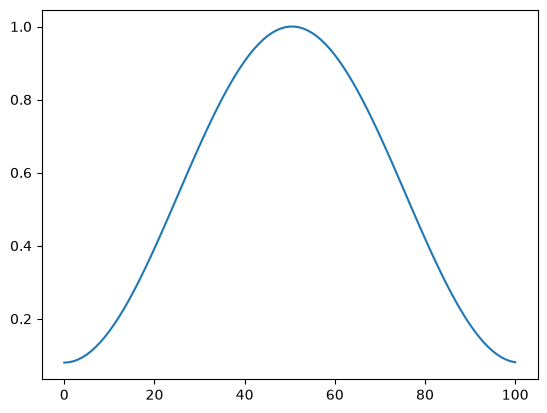

In [103]:
win = sgnl.get_window('hamming', 101)
plt.plot(win)

## Band-pass FIR behaviour vs numtaps and bandwidth

Only the band-pass filter (`bp_taps`) has a declared bandwidth -- `causal_hilbert_fir` is broadband and doesn't need this check. This shows why bandwidth and numtaps are coupled: below a certain numtaps, shrinking the declared bandwidth barely changes the actual shape of the filter, because the filter's own transition width already dominates.

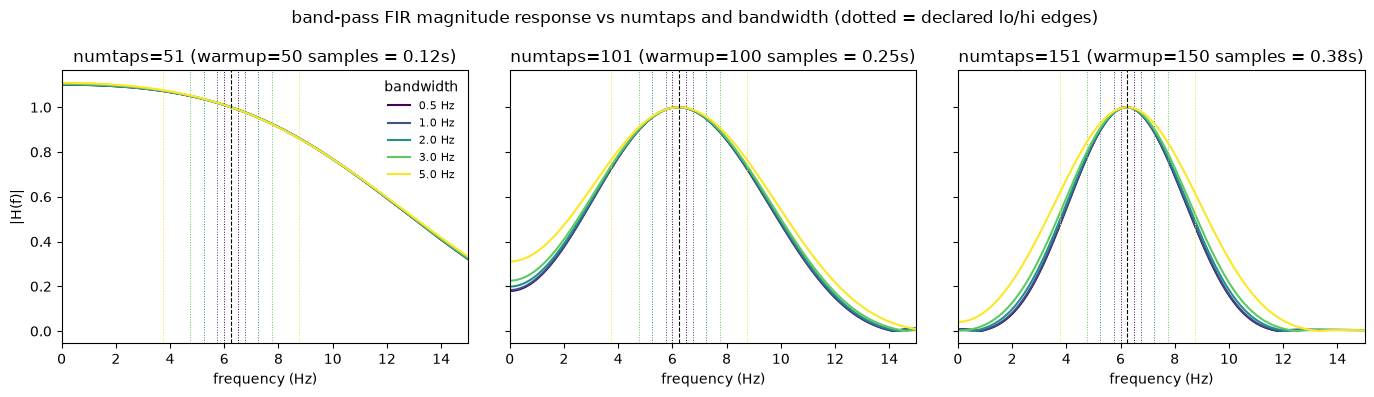

In [135]:
numtaps_grid = [51, 101, 151]
bw_grid = [0.5, 1.0, 2.0, 3.0, 5.0]
bw_colors = plt.cm.viridis(np.linspace(0, 1, len(bw_grid)))

fig, axs = plt.subplots(1, len(numtaps_grid), figsize=(14, 4), sharey=True)
for ax, nt in zip(axs, numtaps_grid):
    for bw, col in zip(bw_grid, bw_colors):
        lo_, hi_ = peak_f - bw / 2, peak_f + bw / 2
        taps_ = sgnl.firwin(nt, [lo_, hi_], pass_zero=False, fs=fs)
        w, h = sgnl.freqz(taps_, worN=4096, fs=fs)
        ax.plot(w, np.abs(h), color=col, label=f"{bw:.1f} Hz")
        ax.axvline(lo_, color=col, ls="dotted", lw=0.7)
        ax.axvline(hi_, color=col, ls="dotted", lw=0.7)
    ax.axvline(peak_f, color="k", ls="dashed", lw=0.8)
    ax.set_xlim(0, 15)
    ax.set_title(f"numtaps={nt} (warmup={nt - 1} samples = {(nt - 1) / fs:.2f}s)")
    ax.set_xlabel("frequency (Hz)")
axs[0].set_ylabel("|H(f)|")
axs[0].legend(title="bandwidth", frameon=False, fontsize=8)
fig.suptitle("band-pass FIR magnitude response vs numtaps and bandwidth (dotted = declared lo/hi edges)")
fig.tight_layout()

## The numtaps / warmup / bandwidth tradeoff

`firwin`'s declared cutoff frequencies (`lo`, `hi`) are only the *asymptotic* -6dB points of the transition -- the filter only actually achieves that selectivity once enough taps have sharpened the transition down to it. Below, for each declared bandwidth, we measure the filter's real -3dB bandwidth as a function of `numtaps` (and, on the top axis, the resulting warmup in seconds): at low `numtaps` all declared bandwidths collapse onto the same curve (the filter is far broader than requested, dominated by its own transition width, not by what you asked for), and only converge to the declared value once `numtaps` -- and therefore warmup -- gets large enough. That convergence is the whole tradeoff: a truly narrow, selective filter costs more history before its output is trustworthy.

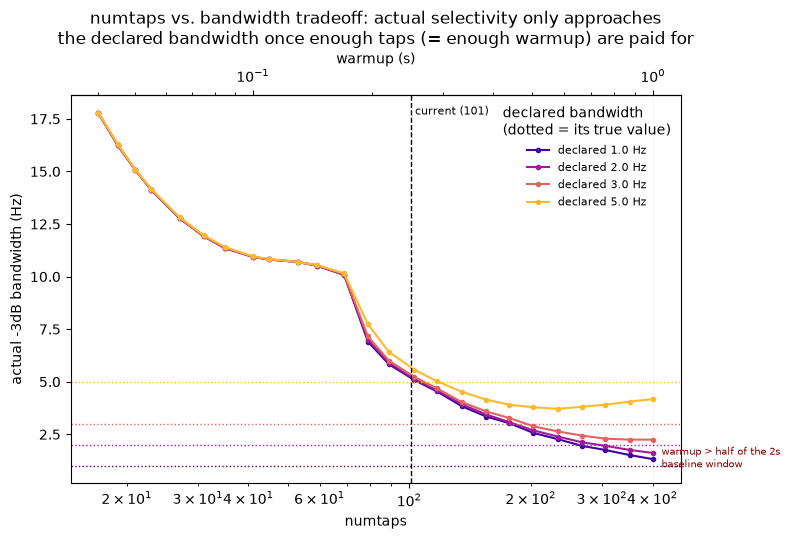

In [136]:
def actual_m3db_bandwidth(bw_declared, numtaps, fs, center):
    """Real -3dB full width of the band-pass filter's central lobe (vs. the declared bw)."""
    lo, hi = center - bw_declared / 2, center + bw_declared / 2
    taps = sgnl.firwin(numtaps, [lo, hi], pass_zero=False, fs=fs)
    w, h = sgnl.freqz(taps, worN=8192, fs=fs)
    mag = np.abs(h)
    above = mag >= (1 / np.sqrt(2))
    if not above.any():
        return np.nan
    idx = np.where(above)[0]
    center_idx = np.argmin(np.abs(w - center))
    lo_i = idx[idx <= center_idx].min() if (idx <= center_idx).any() else idx.min()
    hi_i = idx[idx >= center_idx].max() if (idx >= center_idx).any() else idx.max()
    return w[hi_i] - w[lo_i]


bw_declared_list = [1.0, 2.0, 3.0, 5.0]
numtaps_grid = np.unique(np.round(np.geomspace(15, 401, 25) / 2).astype(int) * 2 + 1)
tradeoff_colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(bw_declared_list)))

fig, ax = plt.subplots(figsize=(8, 5.5))
for bw, col in zip(bw_declared_list, tradeoff_colors):
    actuals = [actual_m3db_bandwidth(bw, nt, fs, peak_f) for nt in numtaps_grid]
    ax.plot(numtaps_grid, actuals, "o-", color=col, ms=3, label=f"declared {bw:.1f} Hz")
    ax.axhline(bw, color=col, ls="dotted", lw=1)

ax.set_xscale("log")
ax.set_xlabel("numtaps")
ax.set_ylabel("actual -3dB bandwidth (Hz)")
ax.axvline(101, color="k", ls="dashed", lw=1)
ax.text(101, ax.get_ylim()[1] * 0.95, " current (101)", fontsize=8, ha="left")
ax.legend(frameon=False, fontsize=8, title="declared bandwidth\n(dotted = its true value)")
ax.set_title("numtaps vs. bandwidth tradeoff: actual selectivity only approaches\n"
             "the declared bandwidth once enough taps (= enough warmup) are paid for")

secax = ax.secondary_xaxis("top", functions=(lambda nt: (nt - 1) / fs, lambda s: s * fs + 1))
secax.set_xlabel("warmup (s)")

# reference: this notebook's baseline window is 2s (200 samples at fs=100Hz) --
# shade where warmup alone would eat more than half of that budget
budget_nt = 0.5 * 2.0 * fs + 1
ax.axvspan(budget_nt, numtaps_grid.max(), color="red", alpha=0.05)
ax.text(budget_nt * 1.05, ax.get_ylim()[1] * 0.05,
        "warmup > half of the 2s\nbaseline window", fontsize=7.5, color="darkred")
fig.tight_layout()

### Single case: declared 2 Hz band-pass

Same idea as above, isolated to `bandwidth=2 Hz`: warmup (red, right axis) grows roughly linearly with `numtaps`, while the actual -3dB bandwidth (blue, left axis) overshoots past the declared 2 Hz line, dips to ~1.5 Hz around `numtaps~130-160`, then rises back toward 2 Hz -- never fully settling even out to `numtaps=401` (4s of warmup).

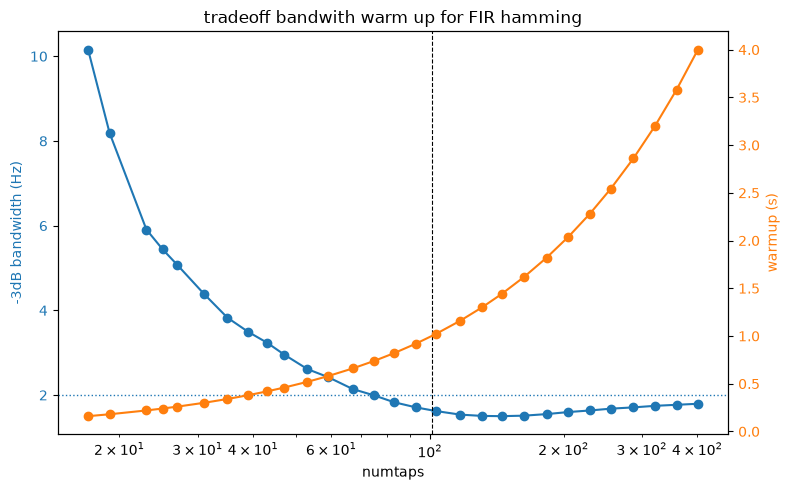

In [151]:
def actual_m3db_edges(bw_declared, numtaps, fs, center):
    lo, hi = center - bw_declared / 2, center + bw_declared / 2
    taps = sgnl.firwin(numtaps, [lo, hi], pass_zero=False, fs=fs)
    w, h = sgnl.freqz(taps, worN=8192, fs=fs)
    mag = np.abs(h)
    above = mag >= (1 / np.sqrt(2))
    if not above.any():
        return np.nan, np.nan
    idx = np.where(above)[0]
    center_idx = np.argmin(np.abs(w - center))
    lo_i = idx[idx <= center_idx].min() if (idx <= center_idx).any() else idx.min()
    hi_i = idx[idx >= center_idx].max() if (idx >= center_idx).any() else idx.max()
    return w[lo_i], w[hi_i]

fs = 100
bw_single = 2.0
numtaps_grid2 = np.unique(np.round(np.geomspace(15, 401, 30) / 2).astype(int) * 2 + 1)
warmups2 = (numtaps_grid2 - 1) / fs
edges2 = np.array([actual_m3db_edges(bw_single, nt, fs, peak_f) for nt in numtaps_grid2])
actual_bw2 = edges2[:, 1] - edges2[:, 0]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(numtaps_grid2, actual_bw2, "o-", color="C0", label="-3dB bandwidth")
ax1.axhline(bw_single, color="C0", ls="dotted", lw=1, label=f"bandwidth ({bw_single:.0f} Hz)")
ax1.set_xscale("log")
ax1.set_xlabel("numtaps")
ax1.set_ylabel("-3dB bandwidth (Hz)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

ax2 = ax1.twinx()
ax2.plot(numtaps_grid2, warmups2, "o-", color="C1", label="warmup")
ax2.set_ylabel("warmup (s)", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

ax1.axvline(101, color="k", ls="dashed", lw=0.8)
# ax1.text(101, ax1.get_ylim()[1] * 0.95, " numtaps=101", fontsize=8)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
# ax1.legend(l1 + l2, lab1 + lab2, loc="upper right")
ax1.set_title(f"tradeoff bandwith warm up for FIR hamming")
fig.tight_layout()

In [150]:
td.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
       'al